# **Bipartite (Medication-Side Effect) Network Analysis**

# Import Libraries

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from adjustText import adjust_text
from networkx import bipartite

# Load Network

In [2]:
# Load the network edge list and node attributes
df_edges = pd.read_csv('../data/processed/bipartite-network-edges.csv')
df_nodes = pd.read_csv('../data/processed/bipartite-network-nodes.csv', sep=';')

# Create the network
B = nx.from_pandas_edgelist(df=df_edges, source='source', target='target')
attribute_dict = df_nodes.set_index('id')['type'].to_dict()
nx.set_node_attributes(G=B, values=attribute_dict, name='type')

# Set the bipartite configurations
medications_set = [n for n, d in B.nodes(data=True) if d['type'] == 'medication']
side_effects_set = [n for n, d in B.nodes(data=True) if d['type'] == 'side effect']
for n, d in B.nodes(data=True):
    B.nodes[n]['bipartite'] = 0 if d['type'] == 'medication' else 1

# Number of Nodes and Edges

In [3]:
# Compute the number of nodes and edges
print(f'Number of nodes: {B.number_of_nodes()}')
print(f'> Medications: {len(medications_set)}')
print(f'> Side effects: {len(side_effects_set)}')
print(f'Number of edges: {B.number_of_edges()}')

Number of nodes: 5585
> Medications: 5453
> Side effects: 132
Number of edges: 45032


# Degree Distributions

In [4]:
# Compute the degree of the nodes in each partition
medications_degree, side_effects_degree = bipartite.degrees(B=B, nodes=side_effects_set)

## Medications

### Descriptive Analysis

In [5]:
# Transform the medications degree list into a DataFrame
df_medications_degree = pd.DataFrame(
    data=medications_degree, columns=['medication', 'degree']
)

# Sort the nodes by descending degree value
df_medications_degree = df_medications_degree \
    .sort_values(by='degree', ascending=False) \
    .reset_index(drop=True)

# Compute the degree distribution statistical description
print('Degree distribution statistics:')
print(df_medications_degree.describe())

# Print the top-5 and bottom-5 nodes by degree
print(f'\nTop-5 nodes by degree: \n{df_medications_degree.head(5)}')
print(f'\nBottom-5 nodes by degree: \n{df_medications_degree.tail(5)}')

Degree distribution statistics:
            degree
count  5453.000000
mean      8.258206
std       4.102914
min       1.000000
25%       5.000000
50%       8.000000
75%      11.000000
max      18.000000

Top-5 nodes by degree: 
           medication  degree
0  diozam 10mg tablet      18
1    bazzy 5mg tablet      18
2  lobazam 2.5 tablet      18
3     talza 10 tablet      18
4  adinep 10mg tablet      18

Bottom-5 nodes by degree: 
                       medication  degree
5448            exal 0.5mg tablet       2
5449     slipizem 5mg suppository       1
5450  juniz rds  suppository 5 mg       1
5451    feb czr 2.5mg suppository       1
5452  juniz rds 2.5mg suppository       1


### Preparation for Plots

In [6]:
# Compute degree sequence
degree_sequence = np.array([d for _, d in medications_degree])

# Compute degree frequencies
degree_values, degree_counts = np.unique(degree_sequence, return_counts=True)

# Compute degree probabilities
degree_prob = degree_counts / degree_counts.sum()

# Compute complementary cumulative distribution function
ccdf = np.cumsum(degree_prob[::-1])[::-1]

### Linear Plot

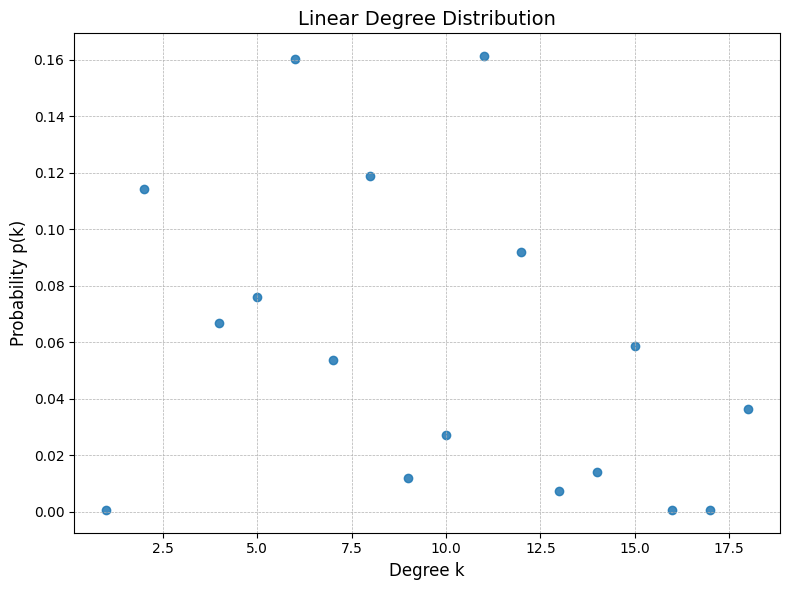

In [7]:
# Scatter plot visualization
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=degree_prob, alpha=0.85)

# Plot configuration
plt.title('Linear Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability p(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

### Log-log Plot

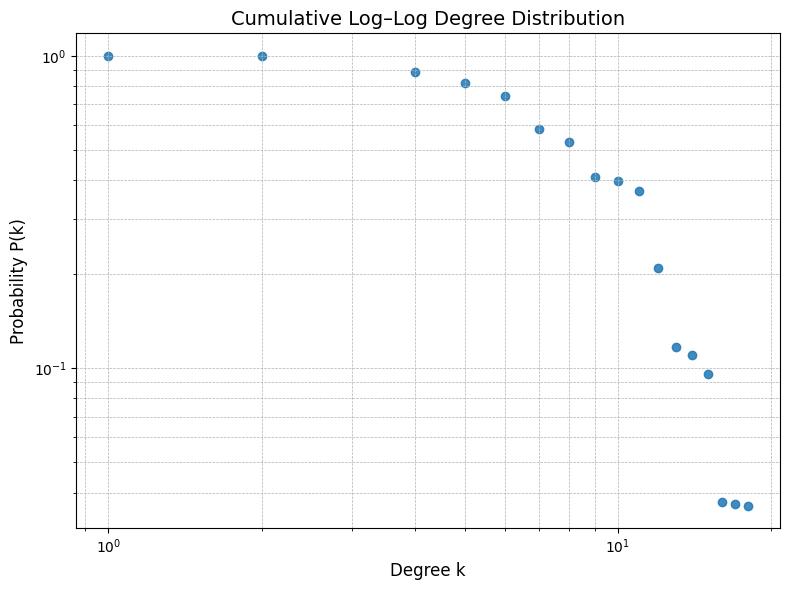

In [8]:
# Scatter plot visualization on log-log scale
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=ccdf, alpha=0.85)
plt.xscale('log')
plt.yscale('log')

# Plot configuration 
plt.title('Cumulative Log–Log Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability P(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

## Side Effects

### Descriptive Analysis

In [9]:
# Transform the side effects degree list into a DataFrame
df_side_effects_degree = pd.DataFrame(
    data=side_effects_degree, columns=['side_effect', 'degree']
)

# Sort the nodes by descending degree value
df_side_effects_degree = df_side_effects_degree \
    .sort_values(by='degree', ascending=False) \
    .reset_index(drop=True)

# Compute the degree distribution statistical description
print('Degree distribution statistics:')
print(df_side_effects_degree.describe())

# Print the top-5 and bottom-5 nodes by degree
print(f'\nTop-5 nodes by degree: \n{df_side_effects_degree.head(5)}')
print(f'\nBottom-5 nodes by degree: \n{df_side_effects_degree.tail(5)}')

Degree distribution statistics:
            degree
count   132.000000
mean    341.151515
std     639.089685
min       1.000000
25%       6.000000
50%      63.500000
75%     295.250000
max    3238.000000

Top-5 nodes by degree: 
         side_effect  degree
0          dizziness    3238
1         drowsiness    2875
2             nausea    2872
3           vomiting    2390
4  memory impairment    2215

Bottom-5 nodes by degree: 
                      side_effect  degree
127            respiratory arrest       1
128         coordination disorder       1
129  gastrointestinal disturbance       1
130                  chalky taste       1
131             numbness in mouth       1


### Preparation for Plots

In [10]:
# Compute degree sequence
degree_sequence = np.array([d for _, d in side_effects_degree])

# Compute degree frequencies
degree_values, degree_counts = np.unique(degree_sequence, return_counts=True)

# Compute degree probabilities
degree_prob = degree_counts / degree_counts.sum()

# Compute complementary cumulative distribution function
ccdf = np.cumsum(degree_prob[::-1])[::-1]

### Linear Plot

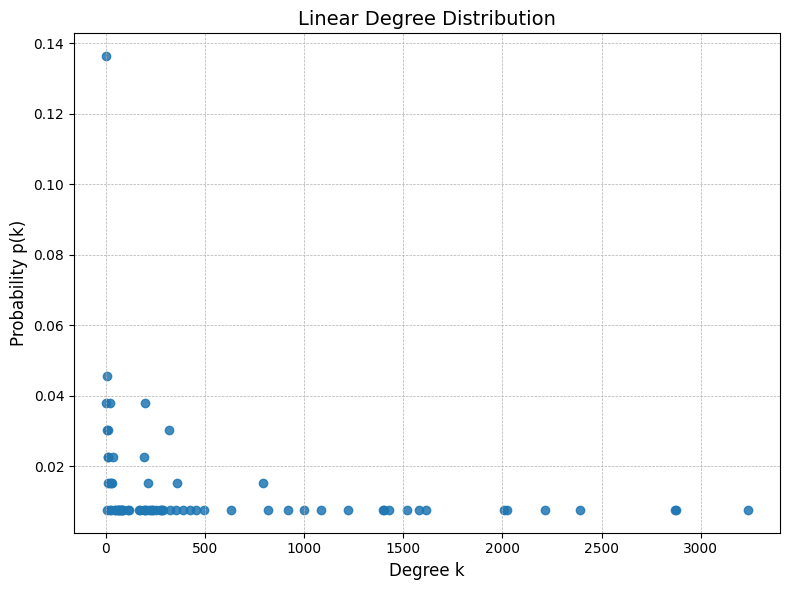

In [11]:
# Scatter plot visualization
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=degree_prob, alpha=0.85)

# Plot configuration
plt.title('Linear Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability p(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

### Log-log Plot

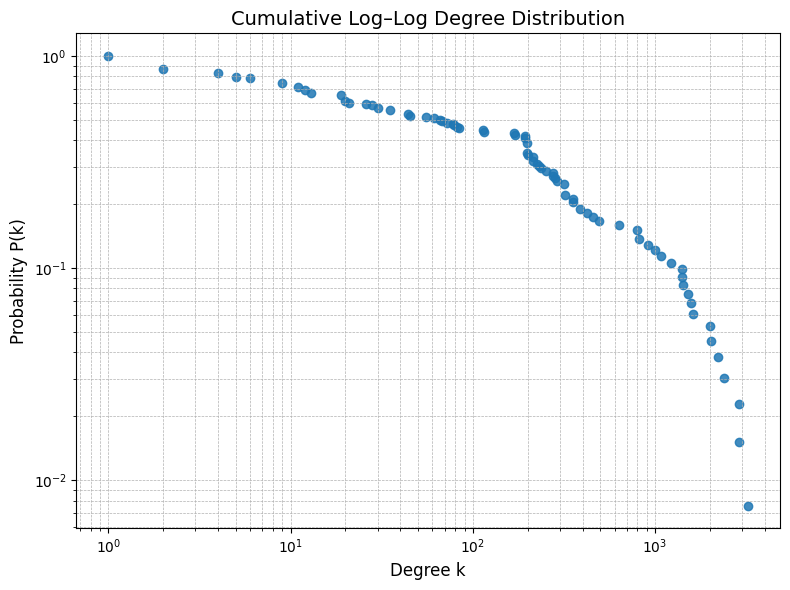

In [12]:
# Scatter plot visualization on log-log scale
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=ccdf, alpha=0.85)
plt.xscale('log')
plt.yscale('log')

# Plot configuration 
plt.title('Cumulative Log–Log Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability P(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

# Connected Components

## Descriptive Analysis

In [13]:
# Compute the number of connected components
connected_components = list(nx.connected_components(B))
print(f'Number of connected components: {len(connected_components)}')

# Compute the connected components size statistical description
cc_sizes = [len(c) for c in connected_components]
cc_sizes_series = pd.Series(cc_sizes)
print('\nConnected components size statistics:')
print(cc_sizes_series.describe())

Number of connected components: 2

Connected components size statistics:
count       2.000000
mean     2792.500000
std      3942.120305
min         5.000000
25%      1398.750000
50%      2792.500000
75%      4186.250000
max      5580.000000
dtype: float64


In [14]:
# Describe each component
for i, component in enumerate(sorted(connected_components, key=len, reverse=True)):
    # Define the subgraph that represent the component
    subgraph = B.subgraph(component)
    
    # Compute the extreme degrees and diameter of the component
    max_degree = max(d for n, d in subgraph.degree())
    min_degree = min(d for n, d in subgraph.degree())
    diameter = nx.diameter(subgraph)

    # Print the description of the component
    print(f'Connected Component {i}:')
    print(f'> Number of nodes = {subgraph.number_of_nodes()}')
    print(f'> Number of edges = {subgraph.number_of_edges()}')
    print(f'> Maximum degree = {max_degree}')
    print(f'> Minimum degree = {min_degree}')
    print(f'> Diameter = {diameter}')
    print()

Connected Component 0:
> Number of nodes = 5580
> Number of edges = 45028
> Maximum degree = 3238
> Minimum degree = 1
> Diameter = 7

Connected Component 1:
> Number of nodes = 5
> Number of edges = 4
> Maximum degree = 4
> Minimum degree = 1
> Diameter = 2



## Giant Component

In [15]:
# Sort the connected components by number of nodes
connected_components = sorted(connected_components, key=len, reverse=True)

# Define the subgraph that represent the giant component
giant_cc = connected_components[0]
giant_cc = B.subgraph(giant_cc)

# Separate the nodes of each partition in the giant component
giant_cc_medications_set, giant_cc_side_effects_set = bipartite.sets(giant_cc)

# Compute the number of nodes per partition in the giant component
print(f'Number of medications: {len(giant_cc_medications_set)}')
print(f'Number of side effects: {len(giant_cc_side_effects_set)}')

Number of medications: 5449
Number of side effects: 131


# Clustering Coefficient

In [16]:
# Compute the average clustering coefficient of the network
print(f'Average clustering coefficient : {bipartite.average_clustering(B)}')

Average clustering coefficient : 0.24121476136794284


# Centralities (Giant Component)

In [17]:
# Create a DataFrame with the side effects and their respective severities
df_side_effects = pd.DataFrame(data=giant_cc_side_effects_set, columns=['id'])
df_side_effects = \
    pd.merge(left=df_nodes, right=df_side_effects, how='left', on='id') \
    .query('type == "side effect"') \
    .reset_index(drop=True) \
    [['id', 'severity']]

## Betweenness

In [18]:
# Compute the betweenness centrality for the giant component nodes
betweenness_centrality = bipartite \
    .betweenness_centrality(G=giant_cc, nodes=giant_cc_medications_set)
df_betweenness_centrality = pd.DataFrame(
    data=betweenness_centrality.items(), columns=['id', 'betweenness_centrality']
)

# Join the metric values in the side effects and severities DataFrame
df_side_effects = pd.merge(
    left=df_side_effects, right=df_betweenness_centrality, how='inner', on='id'
)

# Create a DataFrame only with the data to be printed
df_print = df_side_effects.copy() \
    .sort_values(by='betweenness_centrality', ascending=False) \
    .reset_index(drop=True) \
    [['id', 'severity', 'betweenness_centrality']]

# Print the top-5 and bottom-5 most important nodes
print(f'Top-5 nodes by betweenness: \n{df_print.head(5)}')
print(f'\nBottom-5 nodes by betweenness: \n{df_print.tail(5)}')

Top-5 nodes by betweenness: 
                  id  severity  betweenness_centrality
0         drowsiness  moderate                0.260788
1          dizziness      mild                0.232683
2             nausea      mild                0.130730
3           vomiting  moderate                0.084646
4  memory impairment    severe                0.068854

Bottom-5 nodes by betweenness: 
                               id  severity  betweenness_centrality
126  apnea (absence of breathing)    severe                     0.0
127            respiratory arrest    severe                     0.0
128          circulatory disorder    severe                     0.0
129                         shock    severe                     0.0
130  muscle coordination impaired  moderate                     0.0


## Closeness

In [19]:
# Compute the closeness centrality for the giant component nodes
closeness_centrality = bipartite \
    .closeness_centrality(G=giant_cc, nodes=giant_cc_medications_set)
df_closeness_centrality = pd.DataFrame(
    data=closeness_centrality.items(), columns=['id', 'closeness_centrality']
)

# Join the metric values in the side effects and severities DataFrame
df_side_effects = pd.merge(
    left=df_side_effects, right=df_closeness_centrality, how='inner', on='id'
)

# Create a DataFrame only with the data to be printed
df_print = df_side_effects.copy() \
    .sort_values(by='closeness_centrality', ascending=False) \
    .reset_index(drop=True) \
    [['id', 'severity', 'closeness_centrality']]

# Print the top-5 and bottom-5 most important nodes
print(f'Top-5 nodes by closeness: \n{df_print.head(5)}')
print(f'\nBottom-5 nodes by closeness: \n{df_print.tail(5)}')

Top-5 nodes by closeness: 
                  id  severity  closeness_centrality
0          dizziness      mild              0.561191
1             nausea      mild              0.523138
2         drowsiness  moderate              0.520182
3           vomiting  moderate              0.478983
4  memory impairment    severe              0.462305

Bottom-5 nodes by closeness: 
                                              id  severity  \
126                                   nightmares  moderate   
127                             nasal discomfort      mild   
128                            throat irritation      mild   
129                              cns stimulation    severe   
130  systemic hypertension (high blood pressure)  moderate   

     closeness_centrality  
126              0.277500  
127              0.245390  
128              0.245390  
129              0.201184  
130              0.201184  


## Degree

In [20]:
# Compute the degree centrality for the giant component nodes
degree_centrality = bipartite \
    .degree_centrality(G=giant_cc, nodes=giant_cc_medications_set)
df_degree_centrality = pd.DataFrame(
    data=degree_centrality.items(), columns=['id', 'degree_centrality']
)

# Join the metric values in the side effects and severities DataFrame
df_side_effects = pd.merge(
    left=df_side_effects, right=df_degree_centrality, how='inner', on='id'
)

# Create a DataFrame only with the data to be printed
df_print = df_side_effects.copy() \
    .sort_values(by='degree_centrality', ascending=False) \
    .reset_index(drop=True) \
    [['id', 'severity', 'degree_centrality']]

# Print the top-5 and bottom-5 most important nodes
print(f'Top-5 nodes by degree: \n{df_print.head(5)}')
print(f'\nBottom-5 nodes by degree: \n{df_print.tail(5)}')

Top-5 nodes by degree: 
                  id  severity  degree_centrality
0          dizziness      mild           0.594237
1         drowsiness  moderate           0.527620
2             nausea      mild           0.527069
3           vomiting  moderate           0.438613
4  memory impairment    severe           0.406497

Bottom-5 nodes by degree: 
                               id  severity  degree_centrality
126  apnea (absence of breathing)    severe           0.000184
127            respiratory arrest    severe           0.000184
128          circulatory disorder    severe           0.000184
129                         shock    severe           0.000184
130  muscle coordination impaired  moderate           0.000184


# Communities (Giant Component)

/home/mylena-roberta/Unicamp/MO412/medications-and-side-effects-networks/.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


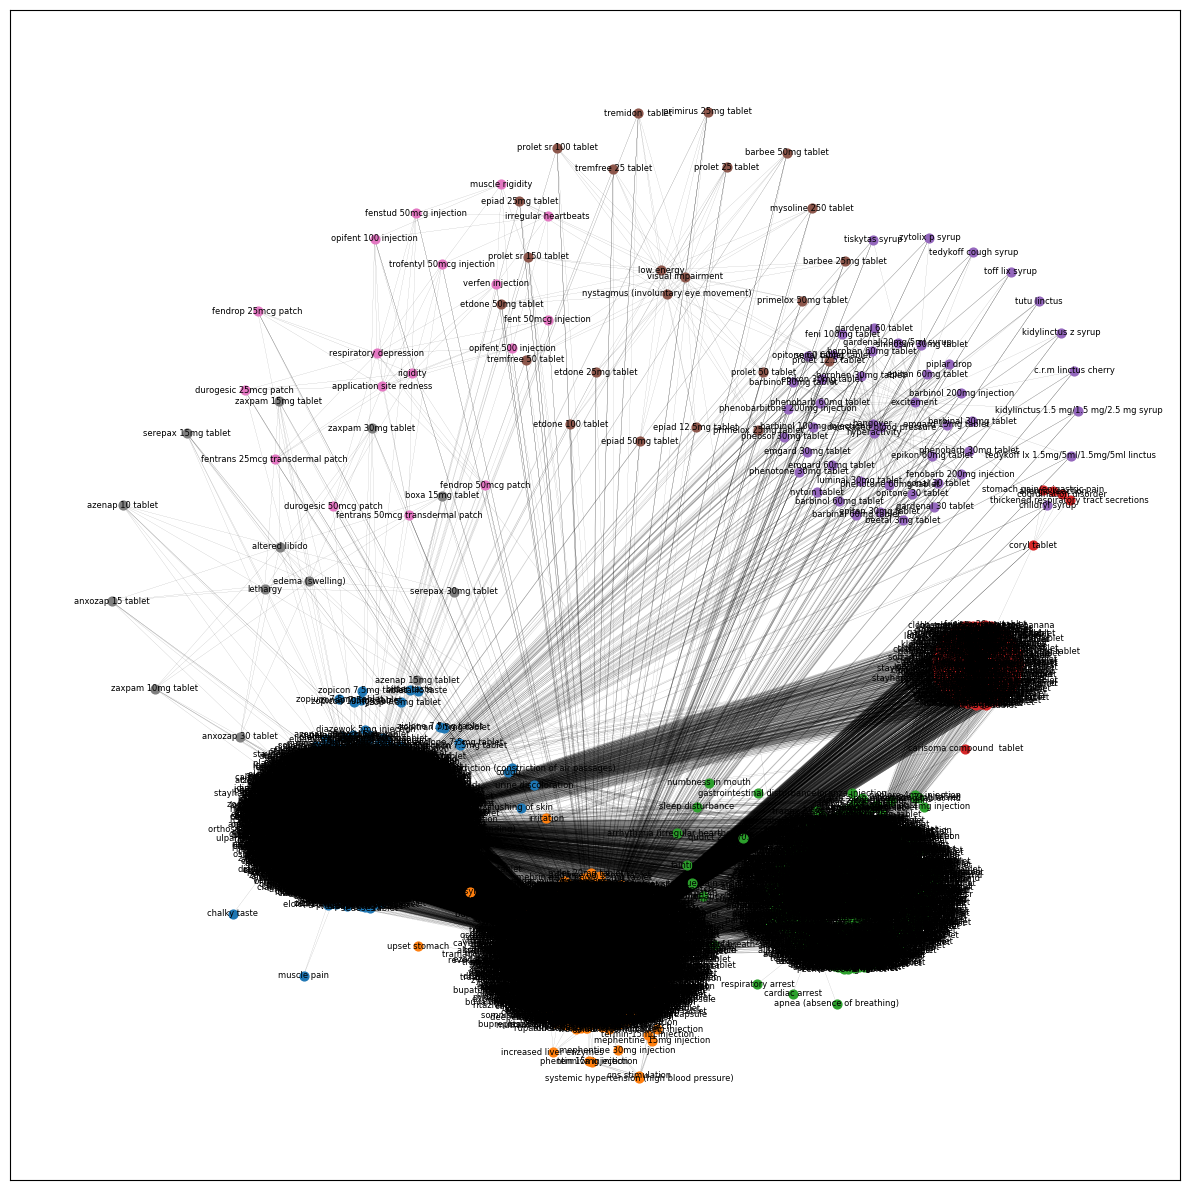

In [21]:
# https://networkx.org/documentation/stable/auto_examples/drawing/plot_clusters.html

communities = nx.community.greedy_modularity_communities(giant_cc)

# communities = nx.community.louvain_communities(giant_cc)

# Compute positions for the node clusters as if they were themselves nodes in a
# supergraph using a larger scale factor
supergraph = nx.cycle_graph(len(communities))
superpos = nx.spring_layout(supergraph, scale=2, seed=429)

# Use the "supernode" positions as the center of each node cluster
centers = list(superpos.values())
pos = {}
for center, comm in zip(centers, communities):
    pos.update(nx.spring_layout(nx.subgraph(giant_cc, comm), center=center, seed=1430))

plt.figure(figsize=(12, 12))

tab_10_colors = plt.get_cmap("tab10").colors

# Nodes colored by cluster
for nodes, clr in zip(communities, tab_10_colors):
    nx.draw_networkx_nodes(giant_cc, pos=pos, nodelist=nodes, node_color=clr, node_size=40)

nx.draw_networkx_edges(giant_cc, pos=pos, width=0.05)

# Add labels
nx.draw_networkx_labels(giant_cc, pos=pos, font_size=6)

# texts = [plt.text(x, y, s, fontsize=6) for s, (x, y) in pos.items()]
# adjust_text(texts)

plt.tight_layout()
plt.show()